In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

import sys
sys.path.append('../../../kaggle')
from utility import classification_utils as cu
from utility import plot_utils as pu

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_features = pd.read_csv("data/current_score.csv", encoding = "latin1", on_bad_lines = 'skip', engine = 'python')
df_target = pd.read_csv("data/current_score_churn.csv", encoding = "latin1", on_bad_lines = 'skip', engine = 'python')
df = pd.merge(df_features, df_target, on = 'Customer_ID', how = 'inner')

In [3]:
merged_shape = df.shape
churn_rate = df['churn'].value_counts(normalize = True) * 100

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(f"Merged Shape: {merged_shape}")
print(f"Churn Rate:\n{churn_rate}")
print(f"\nTop 10 columns with highest missing %:\n{missing_percent.head(10)}")

Merged Shape: (51168, 173)
Churn Rate:
churn
0.0    98.202001
1.0     1.797999
Name: proportion, dtype: float64

Top 10 columns with highest missing %:
mailflag    98.536194
solflag     97.822858
wrkwoman    87.150172
educ1       86.018605
pcowner     81.322311
div_type    80.458490
occu1       72.619606
proptype    71.548624
cartype     67.424953
children    65.552689
dtype: float64


In [4]:
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df_cleaned = df.drop(columns = cols_to_drop)
df_cleaned = df_cleaned.drop(columns = ['Customer_ID'])

In [5]:
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        converted = pd.to_numeric(df_cleaned[col], errors='coerce')
        if converted.isna().mean() < 0.2:
            df_cleaned[col] = converted

In [6]:
num_cols = df_cleaned.select_dtypes(include = [np.number]).columns
cat_cols = df_cleaned.select_dtypes(exclude = [np.number]).columns

df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())
for col in cat_cols:
    if not df_cleaned[col].mode().empty:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print(f"Original columns: {df.shape[1]}")
print(f"Dropped columns (>40% missing): {len(cols_to_drop)}")
print(f"Final columns (including target): {df_cleaned.shape[1]}")
print(f"Total missing values remaining: {df_cleaned.isnull().sum().sum()}")

Original columns: 173
Dropped columns (>40% missing): 13
Final columns (including target): 159
Total missing values remaining: 0


In [7]:
cat_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns
low_cardinality_cols = [col for col in cat_cols if df_cleaned[col].nunique() < 15]
df_cleaned = df_cleaned.drop(columns=[c for c in cat_cols if c not in low_cardinality_cols])

df_encoded = pd.get_dummies(df_cleaned, columns=low_cardinality_cols, drop_first=True)

In [13]:
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X = X.astype(np.float32)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

/home/norbert/.venvs/ml/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


In [14]:
print(f"Shape after encoding: {df_encoded.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"Class distribution in train set:\n{y_train.value_counts(normalize=True)*100}")

Shape after encoding: (51168, 186)
X_train shape: (40934, 185)
Class distribution in train set:
churn
0.0    98.201984
1.0     1.798016
Name: proportion, dtype: float64



Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     10050
         1.0       0.00      0.00      0.00       184

    accuracy                           0.98     10234
   macro avg       0.49      0.50      0.50     10234
weighted avg       0.96      0.98      0.97     10234

ROC-AUC Score: 0.5575


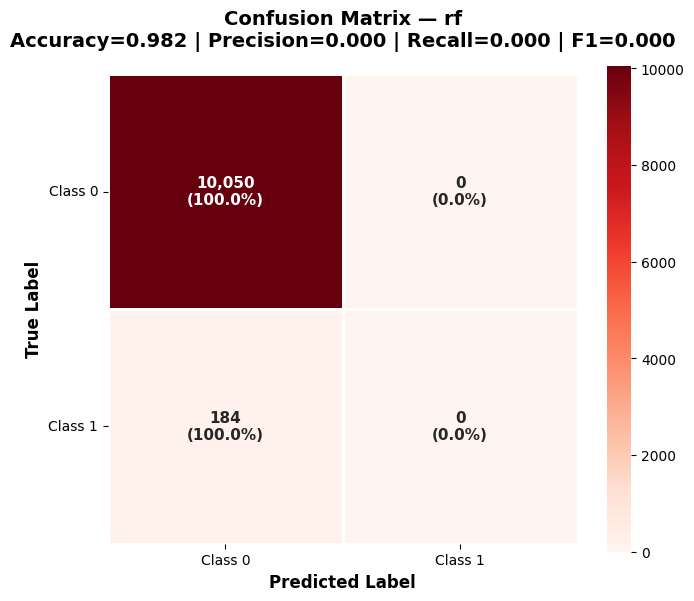

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix — rf\nAccuracy=0.982 | Precision=0.000 | Recall=0.000 | F1=0.000'}, xlabel='Predicted Label', ylabel='True Label'>)

In [27]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
pu.plot_confusion_matrix(y_true = y_test, y_pred = y_pred, model_name = "rf")

XGBoost Report:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     10050
         1.0       0.06      0.04      0.05       184

    accuracy                           0.97     10234
   macro avg       0.52      0.51      0.52     10234
weighted avg       0.97      0.97      0.97     10234

ROC-AUC Score: 0.5741


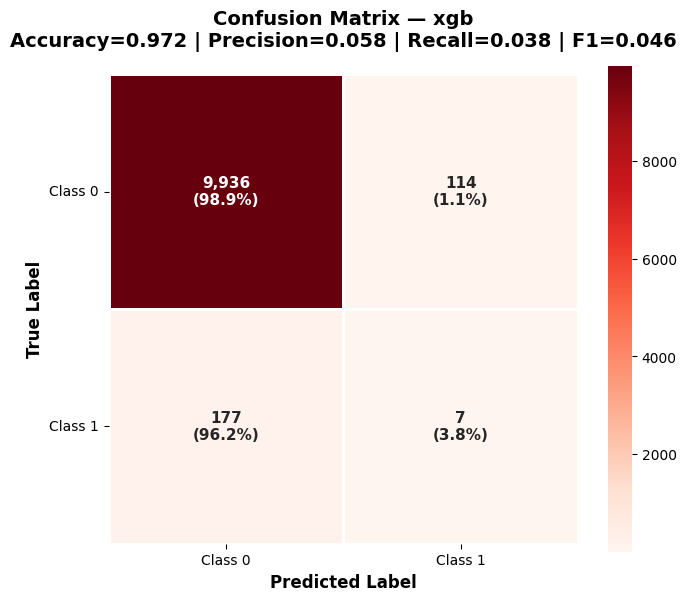

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix — xgb\nAccuracy=0.972 | Precision=0.058 | Recall=0.038 | F1=0.046'}, xlabel='Predicted Label', ylabel='True Label'>)

In [24]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
pu.plot_confusion_matrix(y_true = y_test, y_pred = y_pred_xgb, model_name = "xgb")

Under-sampled Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.57      0.72     10050
         1.0       0.02      0.55      0.04       184

    accuracy                           0.57     10234
   macro avg       0.50      0.56      0.38     10234
weighted avg       0.97      0.57      0.71     10234

ROC-AUC Score: 0.5938


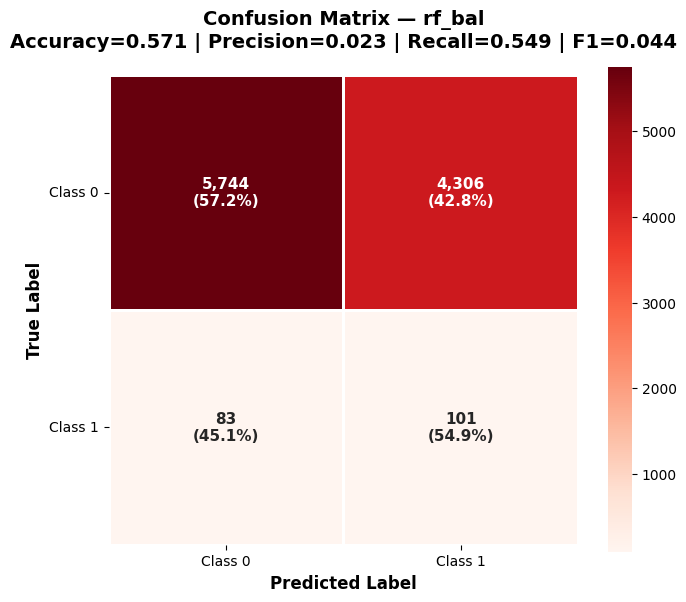

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix — rf_bal\nAccuracy=0.571 | Precision=0.023 | Recall=0.549 | F1=0.044'}, xlabel='Predicted Label', ylabel='True Label'>)

In [25]:
train_data = pd.concat([X_train, y_train], axis = 1)
churn_0 = train_data[train_data['churn'] == 0.0]
churn_1 = train_data[train_data['churn'] == 1.0]

churn_0_sampled = churn_0.sample(n = len(churn_1), random_state = 42)
train_balanced = pd.concat([churn_0_sampled, churn_1])

X_train_bal = train_balanced.drop(columns=['churn'])
y_train_bal = train_balanced['churn']

rf_bal = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42, n_jobs = -1)
rf_bal.fit(X_train_bal, y_train_bal)

y_pred_bal = rf_bal.predict(X_test)
y_prob_bal = rf_bal.predict_proba(X_test)[:, 1]

print("Under-sampled Classification Report:")
print(classification_report(y_test, y_pred_bal))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_bal):.4f}")
pu.plot_confusion_matrix(y_true = y_test, y_pred = y_pred_bal, model_name = "rf_bal")

In [19]:
importances = rf_bal.feature_importances_
feat_names = X_train_bal.columns
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(10)
print(imp_df)

        Feature  Importance
124     eqpdays    0.029225
18   change_mou    0.023013
94       months    0.018046
1      mou_Mean    0.017504
99       totrev    0.016664
103      avgrev    0.015278
100      adjrev    0.015088
19   change_rev    0.014754
107     avg3qty    0.014124
0      rev_Mean    0.014074
